In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv('../data/laptop_price_cleaned.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1303, 49)


,Inches,Ram,Weight,Price_euros,Has_SSD,Has_HDD,Screen_Width,Screen_Height,Company_Acer,Company_Apple,...,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,Cpu_Brand_AMD,Cpu_Brand_Intel,Cpu_Brand_Samsung,Gpu_Brand_AMD,Gpu_Brand_ARM,Gpu_Brand_Intel,Gpu_Brand_Nvidia
0,13.3,8,1.37,1339.69,1,0,2560,1600,False,True,...,False,False,True,False,True,False,False,False,True,False
1,13.3,8,1.34,898.94,0,0,1440,900,False,True,...,False,False,True,False,True,False,False,False,True,False
2,15.6,8,1.86,575.00,1,0,1920,1080,False,False,...,False,False,False,False,True,False,False,False,True,False
3,15.4,16,1.83,2537.45,1,0,2880,1800,False,True,...,False,False,True,False,True,False,True,False,False,False
4,13.3,8,1.37,1803.60,1,0,2560,1600,False,True,...,False,False,True,False,True,False,False,False,True,False


In [10]:
# Target (price to predict)
y = df['Price_euros']

# Features (all other columns)
X = df.drop('Price_euros', axis=1)

In [11]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("Price range:", y.min(), "to", y.max(), "euros")

Features shape: (1303, 48)
Target shape: (1303,)
Price range: 174.0 to 6099.0 euros


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

Training data: 1042
Testing data: 261


In [16]:
def evaluate_model(name, y_test, y_pred):
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [18]:
# Model: Linear Regression
lr_model = LinearRegression()

In [19]:
# The model looks at the laptop specs (X_train) and learns the prices (y_train)
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](48,)","[-29.97, 60.6 ,188.02,...,-47.61, 65.47, 59.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](48,)","['Inches','Ram','Weight',...,'Gpu_Brand_ARM','Gpu_Brand_Intel', 'Gpu_Brand_Nvidia']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,147.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,48
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,41


In [20]:
lr_pred = lr_model.predict(X_test)
lr_results = evaluate_model('Linear Regression', y_test, lr_pred)

Model: Linear Regression
  R² Score : 0.7457  (1.0 = perfect)
  MAE      : €253.65  (average prediction error)
  RMSE     : €359.43



In [21]:
# Model: Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

In [22]:
ridge_results = evaluate_model('Ridge Regression', y_test, ridge_pred)

Model: Ridge Regression
  R² Score : 0.7425  (1.0 = perfect)
  MAE      : €253.34  (average prediction error)
  RMSE     : €361.63



In [23]:
# Model: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [24]:
# Building 100 trees
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [25]:
rf_results = evaluate_model('Random Forest', y_test, rf_pred)

Model: Random Forest
  R² Score : 0.7741  (1.0 = perfect)
  MAE      : €214.04  (average prediction error)
  RMSE     : €338.76



In [26]:
results_df = pd.DataFrame([lr_results, ridge_results, rf_results])
print('Model Comparison:')
results_df

Model Comparison:


,Model,R2,MAE (€),RMSE (€)
0,Linear Regression,0.7457,253.65,359.43
1,Ridge Regression,0.7425,253.34,361.63
2,Random Forest,0.7741,214.04,338.76


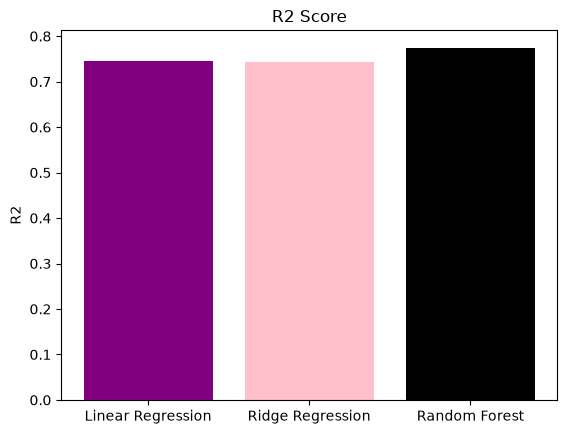

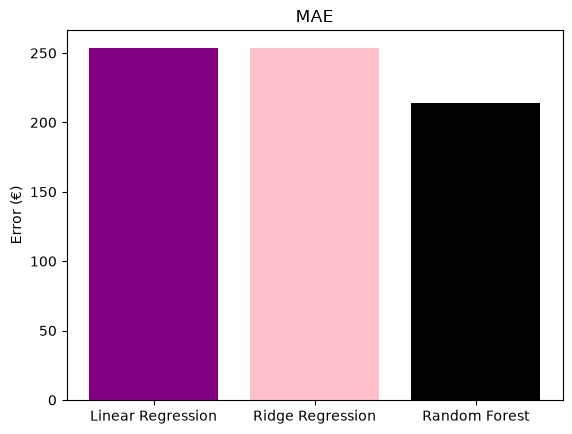

Best model: Random Forest


In [34]:
# Compare R² scores
plt.bar(results_df['Model'], results_df['R2'],color=['purple', 'pink', 'black'])
plt.title("R2 Score")
plt.ylabel("R2")
plt.show()

# Compare MAE
plt.bar(results_df['Model'], results_df['MAE (€)'],color=['purple', 'pink', 'black'])
plt.title("MAE")
plt.ylabel("Error (€)")
plt.show()

# Best model
best = results_df.loc[results_df['R2'].idxmax(), 'Model']
print("Best model:", best)

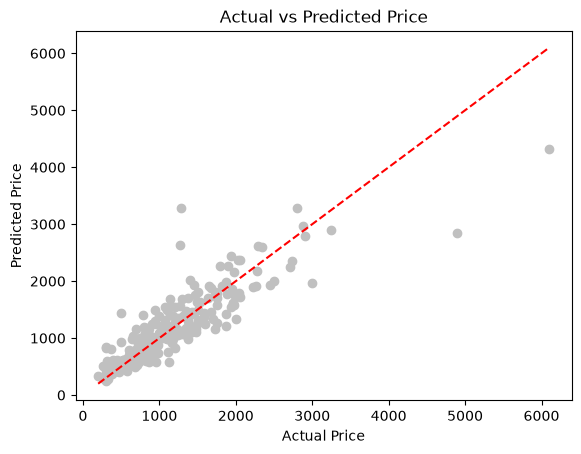

In [38]:
plt.scatter(y_test, rf_pred, color='silver')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')

plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [40]:
# Get feature importances from the trained Random Forest
feature_importances = rf_model.feature_importances_
feature_names= X.columns

In [43]:
importance_df = pd.DataFrame({'Feature':feature_names,'Importance':feature_importances}).sort_values('Importance',ascending=False).reset_index(drop=True)

In [44]:
print('Top 15 most important features:')
print(importance_df.head(15).to_string(index=False))

Top 15 most important features:
             Feature  Importance
                 Ram    0.588145
              Weight    0.122390
   TypeName_Notebook    0.055050
              Inches    0.031764
        Screen_Width    0.023410
TypeName_Workstation    0.021375
       Screen_Height    0.018895
     OpSys_Windows 7    0.017627
             Has_SSD    0.015849
       Company_Razer    0.015734
          Company_HP    0.010606
      Company_Lenovo    0.008954
        Company_Asus    0.008451
        Company_Dell    0.007820
  TypeName_Ultrabook    0.007700


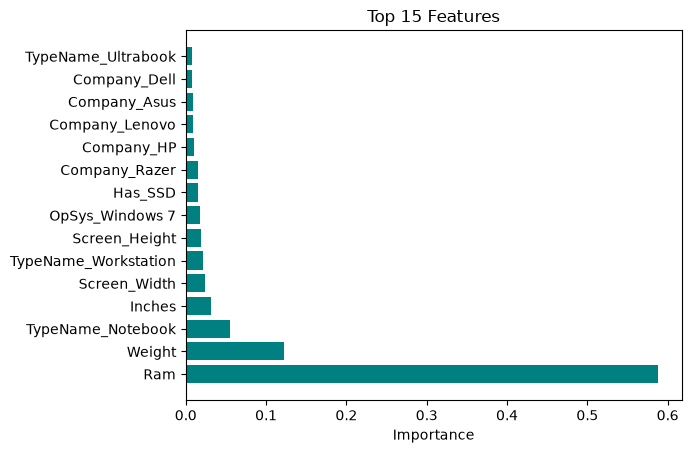

In [49]:
# Top 15 features
top15 = importance_df.head(15)

plt.barh(top15['Feature'], top15['Importance'], color='teal')
plt.title("Top 15 Features")
plt.xlabel("Importance")
plt.show()

In [51]:
# First 5 laptops from test set
sample_X = X_test.head(5)
sample_y = y_test.head(5)

# Predict prices
sample_pred = rf_model.predict(sample_X)

In [52]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': sample_y,
    'Predicted': sample_pred
})

print(comparison)

      Actual    Predicted
479   1672.0  1452.556667
1022  1149.0  1571.546000
298    499.0   538.951333
1265   899.0  1015.234333
774   1244.0  1351.800400


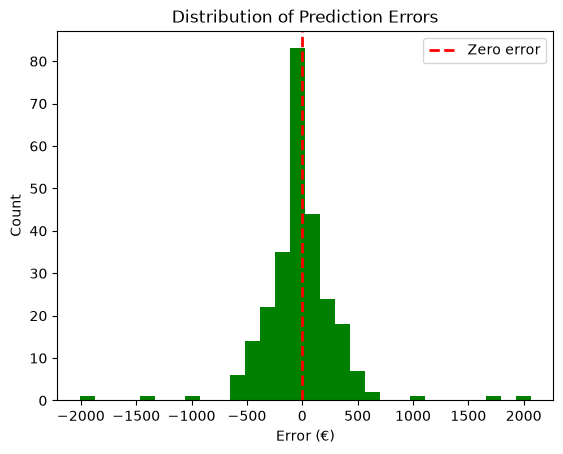

Average error: -20.32263154706615


In [58]:
# Calculate errors
errors = y_test - rf_pred

plt.hist(errors, bins=30, color='green')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (€)")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Average error:", np.mean(errors))